In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
from scipy.stats import ttest_ind

In [ ]:
# user-defined paths
base_dir = '../../../../datos-notebooks/1.global-data-cba/'
ground_data_name = 'ground_data_170226_shadow_sun.csv'

In [ ]:
# derived paths
ground_data_path = os.path.join(base_dir, 'MRT-prediction/ground_data', ground_data_name)

In [ ]:
df = pd.read_csv(ground_data_path, sep=",")

#### correcting T1 values
TG1_corr = 0.639 * TG1 + 9.681 from notebook 1.4.4.1.

TG1: Sper Scientific 800036

TG2: TM-188D TENMARS

In [ ]:
# Create corrected TG column based on instrument used
df["tg_corr"] = np.where(
    df["instrument (1 viejo 2 nuevo)"] == 1,
    0.639 * df["TG"] + 9.681,   # apply correction for A1 based on notebook 1.4.4.1.
    df["TG"]                   # keep original value for A2
)

In [ ]:
# Convert time to datetime
df["time"] = pd.to_datetime(df["time"], format="%H:%M")

fig = px.scatter(
    df,
    x="time",
    y="tg_corr",
    color="condition",
    color_discrete_map={
        "sun": "orange",
        "shadow": "blue"
    },
    labels={
        "time": "Hora",
        "tg_corr": "TG corregida (°C)",
        "condition": "Condición"
    },
    category_orders={"condition": ["sun", "shadow"]},
    hover_data=["TG", "tg_corr", "wind"],
    title="TG corregida a lo largo del tiempo"
)

# Translate legend without changing the dataframe values
fig.for_each_trace(lambda t: t.update(
    name={"sun": "Sol", "shadow": "Sombra"}.get(t.name, t.name)
))
fig.update_xaxes(tickformat="%H:%M")
fig.show()

#### MRT computing

In [ ]:
# Fill NaN values
df["TA (t)"] = df["TA (t)"].fillna(29.5)
df["wind_corr"] = 0.01


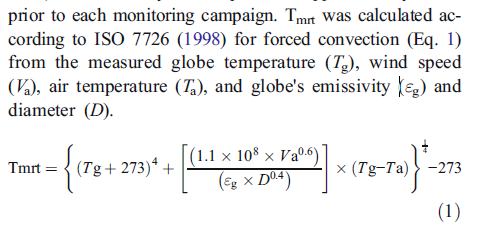

In [ ]:
# Parameters
eps = 0.95
D1 = 0.04   # diameter of globe 1 [m] 
D2 = 0.05  # diameter of globe 2 [m] -- we use this one because TG values are calibrated to Thermometer 2

# MRT calculation using row-specific diameter
df["MRT"] = (
    (
        (df["tg_corr"] + 273.15)**4
        + (1.1e8 * df["wind_corr"]  **0.6 / (eps * D2**0.4)) * (df["tg_corr"] - df["TA (t)"]) # use D2 because TG values are calibrated to Thermometer 2
    )**0.25
    - 273.15
)

In [ ]:
# Boxplot of corrected MRT by condition
df.boxplot(column="MRT", by="condition")

plt.title("MRT for sky condition")
plt.suptitle("")  
plt.xlabel("Condition")
plt.ylabel("MRT (°C)")
plt.show()


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

for condition, color, label in [("sun", "orange", "Sol"), ("shadow", "blue", "Sombra")]:
    mask = df["condition"] == condition
    ax.scatter(df.loc[mask, "time"], df.loc[mask, "MRT"], 
               color=color, label=label, s=40)

ax.set_xlabel("Hora")
ax.set_ylabel("MRT (°C)")
ax.set_title("MRT en el tiempo")
ax.legend(title="Condición")
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%H:%M"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The values in the first 10' show the time that takes for each thermometer to adapt. Those values are filtered below

In [ ]:
df_filtrado = df[df["time"] >= pd.to_datetime("12:09", format="%H:%M")]

In [ ]:
fig, ax = plt.subplots()

df_filtrado.groupby("condition")["MRT"].apply(list)

data = [df_filtrado[df_filtrado["condition"] == c]["MRT"].values 
        for c in ["shadow", "sun"]]

ax.boxplot(data, labels=["Sombra", "Sol"])
ax.set_xlabel("Condición")
ax.set_ylabel("MRT (°C)")
ax.set_title("MRT por condición")
plt.tight_layout()
plt.show()

In [ ]:
# Compute mean by condition
means = df_filtrado.groupby("condition")["MRT"].mean()

# Difference sun - shadow
diff = means["sun"] - means["shadow"]
diff = round(diff, 2)

means, diff

In [ ]:
# t-test
sun = df_filtrado[df_filtrado["condition"] == "sun"]["MRT"]
shadow = df_filtrado[df_filtrado["condition"] == "shadow"]["MRT"]

ttest_ind(sun, shadow, equal_var=False) 

In [ ]:
sun = df_filtrado[df_filtrado["condition"] == "sun"]["MRT"]
shadow = df_filtrado[df_filtrado["condition"] == "shadow"]["MRT"]

plt.hist(sun, bins=8, alpha=0.6, label="Sun", color="orange")
plt.hist(shadow, bins=8, alpha=0.6, label="Shadow", color="blue")

plt.xlabel("MRT (°C)")
plt.ylabel("Frecuencia")
plt.title("Distribuction of MRT")
plt.legend()
plt.show()